# Weblate data vizualisation
Romain Darous. <br> <br>

After collecting Weblate translation files, stored language per language in the folder ``/os_by_language``, it is interesting to take a look at the distribution of the available data per language.

### Importing required modules

In [2]:
import matplotlib.pyplot as plt
import os
import pandas as pd
from collections import defaultdict
import numpy as np

### Storing data analytics
- ``file_nb`` : number of .csv files per language,
- ``string_nb`` : number of translated strings per language,
- ``word_nb`` : number of translated words per language (with duplicates).

In [5]:
languages = os.listdir("./os_by_language")
stats = defaultdict( lambda : defaultdict(int))

for language in languages :
    path = f'./by_language/{language}'
    files = os.listdir(f'./os_by_language/{language}')
    if len(files) == 0 :
        os.rmdir(path)
        continue
    stats[language]["file_nb"] = len(files)
    for file in files :
        df = pd.read_csv(f'./os_by_language/{language}/{file}')
        stats[language]["string_nb"] += df.shape[0]
        try :
            for string in df["target"] :
                if not pd.isnull(string):
                    stats[language]["word_nb"] += len(string.split(' '))
        except :
            print(df, file)

### Displaying data analytics

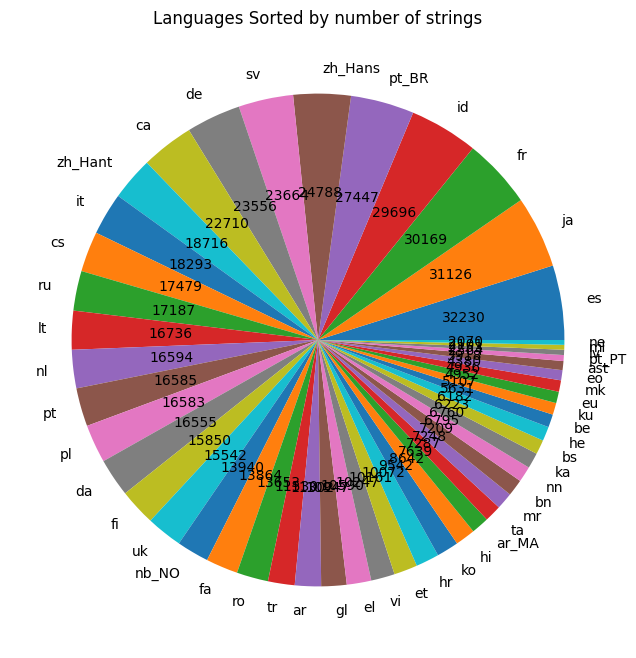

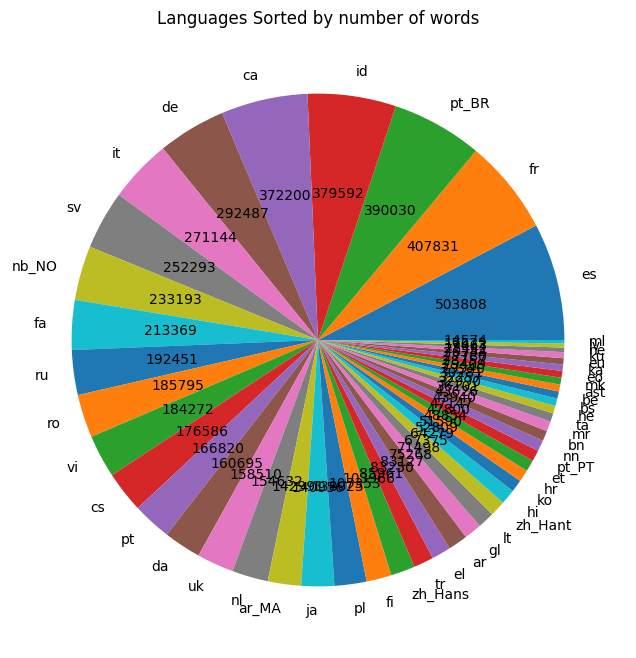

In [6]:
# Sort languages by number of strings
sorted_languages_by_strings = sorted(stats.keys(), key=lambda x: stats[x]['string_nb'], reverse=True)
num_strings = [stats[language]['string_nb'] for language in sorted_languages_by_strings]

plt.figure(figsize=(14, 8))  # Increase the figure size
plt.pie(num_strings[:50], labels=sorted_languages_by_strings[:50], autopct=lambda pct: f"{pct * sum(num_strings[:50]) / 100:.0f}")
plt.title('Languages Sorted by number of strings')
plt.show()

# Sort languages by number of words
sorted_languages_by_words = sorted(stats.keys(), key=lambda x: stats[x]['word_nb'], reverse=True)
num_words = [stats[language]['word_nb'] for language in sorted_languages_by_words]

plt.figure(figsize=(14, 8))  # Increase the figure size
plt.pie(num_words[:50], labels=sorted_languages_by_words[:50], autopct=lambda pct: f"{pct * sum(num_words[:50]) / 100:.0f}")
plt.title('Languages Sorted by number of words')
plt.show()


### Statistics on the dataset
First one may take a look at the common statistic values of the dataset :
- Mean and standard deviation of the number of translated words and strings,
- Most and least translated languages for data imbalance evaluation.

In [4]:
# Calculate the mean and standard deviation
mean_strings = np.mean(num_strings)
mean_words = np.mean(num_words)
std_strings = np.std(num_strings)
std_words = np.std(num_words)

mean_std_df = pd.DataFrame({'Mean nb of strings': [np.round(mean_strings)],
                            'Mean nb of words': [np.round(mean_words)],
                            'Standard Deviation of strings': [np.round(std_strings)],
                            'Standard Deviation of words': [np.round(std_words)]})
mean_std_df

,Mean nb of strings,Mean nb of words,Standard Deviation of strings,Standard Deviation of words
0,11188.0,110172.0,8710.0,118165.0


In [9]:
df = pd.DataFrame({'Language': [sorted_languages_by_words[0], sorted_languages_by_words[-1]],
                       'Number of strings': [num_strings[0], num_strings[-1]],
                       'Number of words': [num_words[0], num_words[-1]]})
df



,Language,Number of strings,Number of words
0,es,23240,425800
1,gv,2,5
